In [140]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [141]:
import sys
import os

# Add the project root (one level up from 'scripts/') to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
print(project_root)
if project_root not in sys.path:
    sys.path.append(project_root)

from utils import utils

C:\Users\Or Shkuri\PycharmProjects\MissingFeatures


## Using the actual dataset

In [142]:
dataset_name = 'electricity'
data_path = f"../../data/{dataset_name}/train/data.csv"
df = pd.read_csv(data_path, header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.469493,0.234043,0.046025,0.359268,0.003043,0.373641,0.556140,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.023008,0.361702,0.089738,0.313746,0.003467,0.422915,0.414912,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.907880,0.744681,0.043953,0.474412,0.002985,0.527965,0.364035,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.473253,0.851064,0.024919,0.400625,0.001676,0.320818,0.457895,0.0


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       10001 non-null  float64
 1   1       10001 non-null  float64
 2   2       10001 non-null  float64
 3   3       10001 non-null  float64
 4   4       10001 non-null  float64
 5   5       10001 non-null  float64
 6   6       10001 non-null  float64
 7   7       10001 non-null  float64
 8   8       10001 non-null  float64
 9   9       10001 non-null  float64
 10  10      10001 non-null  float64
 11  11      10001 non-null  float64
 12  12      10001 non-null  float64
 13  13      10001 non-null  float64
 14  14      10001 non-null  float64
dtypes: float64(15)
memory usage: 1.1 MB


### Check missing values

In [144]:
pd.DataFrame({'total_missing': df.isnull().sum()}).sum()

total_missing    0
dtype: int64

### Statistics of features

In [145]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
count,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000
mean,0.143886,0.143786,0.145485,0.136686,0.148085,0.141286,0.142786,0.500302,0.504101,0.058847,0.427369,0.004621,0.423387,0.503404,0.427957
std,0.350991,0.350890,0.352891,0.344405,0.356887,0.351193,0.354133,0.346915,0.307280,0.098640,0.189622,0.110877,0.167228,0.197552,0.512869
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001488,0.000000,0.037286,0.002632,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.031901,0.234043,0.034977,0.312556,0.002268,0.370274,0.414912,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.456351,0.510638,0.048487,0.444808,0.003467,0.422915,0.414912,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.880536,0.765957,0.073406,0.537489,0.003467,0.467374,0.609211,1.000000
max,1.000000,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.000000


### Plot numerical features

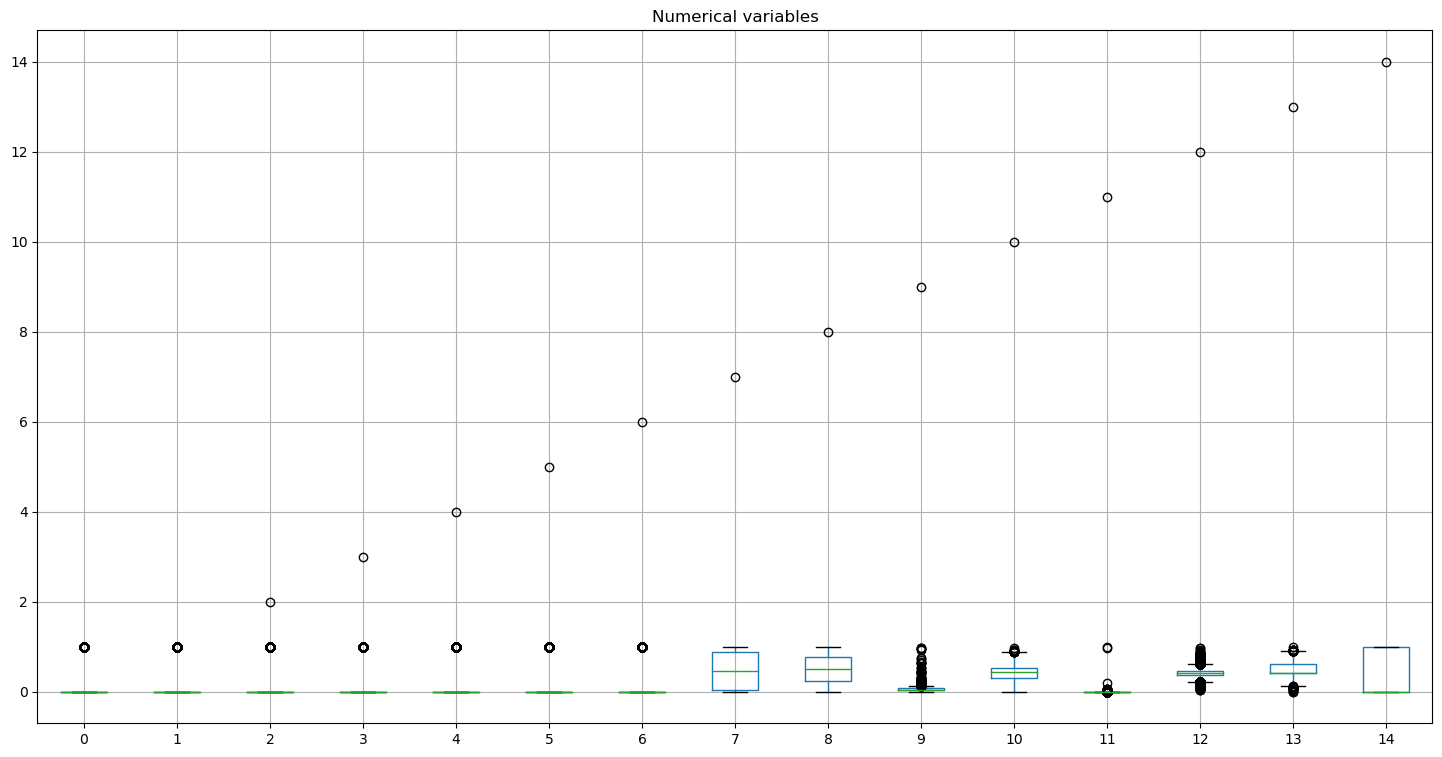

In [146]:
plt.figure(figsize=(18, 9))
columns = list(df.columns)
df.boxplot()
plt.title("Numerical variables")
plt.show()

We can observe that features have different scaling and also some are categorical (only have a few uniques)

### Understand distribution of features

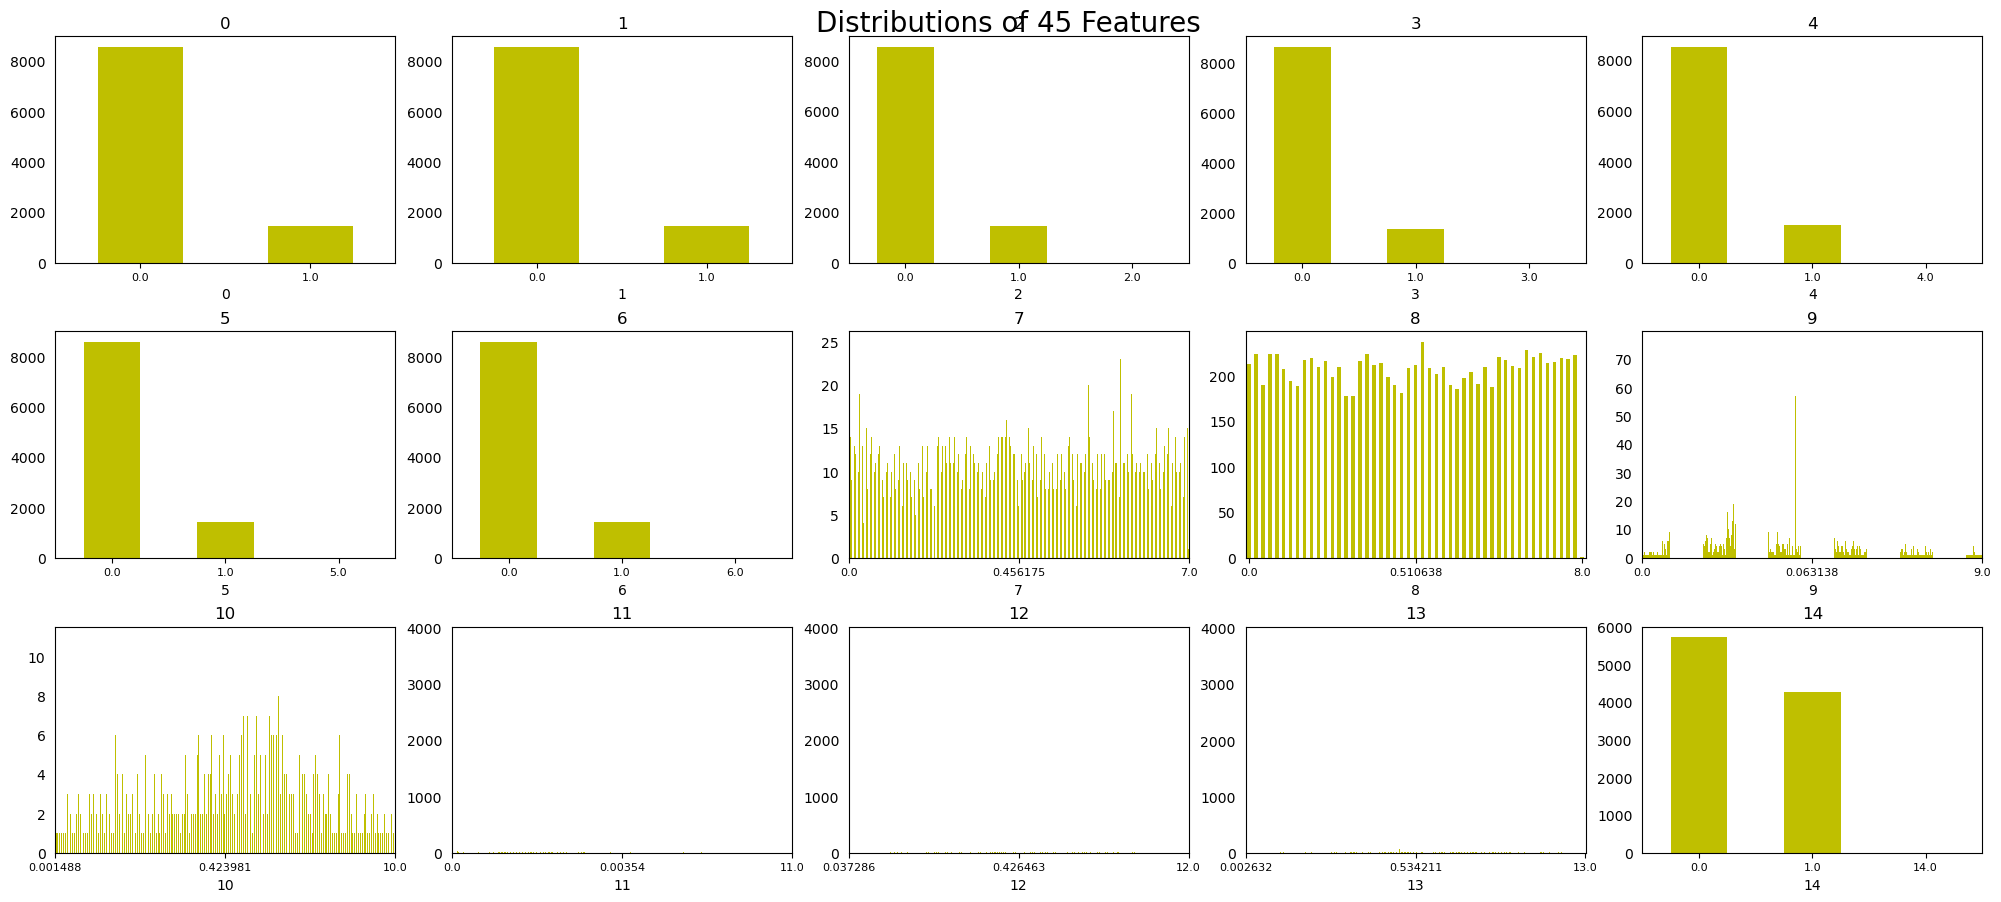

In [148]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dist(col, ax):
    counts = df[col].dropna().value_counts().sort_index()
    counts.plot(kind='bar', color='y', ax=ax)

    ax.set_xlabel(col, fontsize=10)
    ax.set_title(f"{col}", fontsize=12)

    num_bars = len(counts)
    if num_bars > 3:
        positions = [0, num_bars // 2, num_bars - 1]
        labels = [str(counts.index[pos]) for pos in positions]
        ax.set_xticks(positions)
        ax.set_xticklabels(labels, rotation=0, fontsize=8)
    else:
        ax.set_xticklabels(counts.index, rotation=0, fontsize=8)

    # Optional: reduce y-axis ticks clutter
    ax.yaxis.set_ticks_position('none') 
    return ax

num_features = 15
cols = list(df.columns)[:num_features]

rows, cols_per_row = 3, 5
fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row*4, rows*3))
fig.tight_layout(h_pad=3, w_pad=1)
fig.subplots_adjust(top=0.95)

for i, ax in enumerate(axes.flat):
    if i < num_features:
        plot_dist(cols[i], ax)
    else:
        ax.axis('off')  # turn off unused subplots

fig.suptitle("Distributions of 45 Features", fontsize=20)
plt.show()


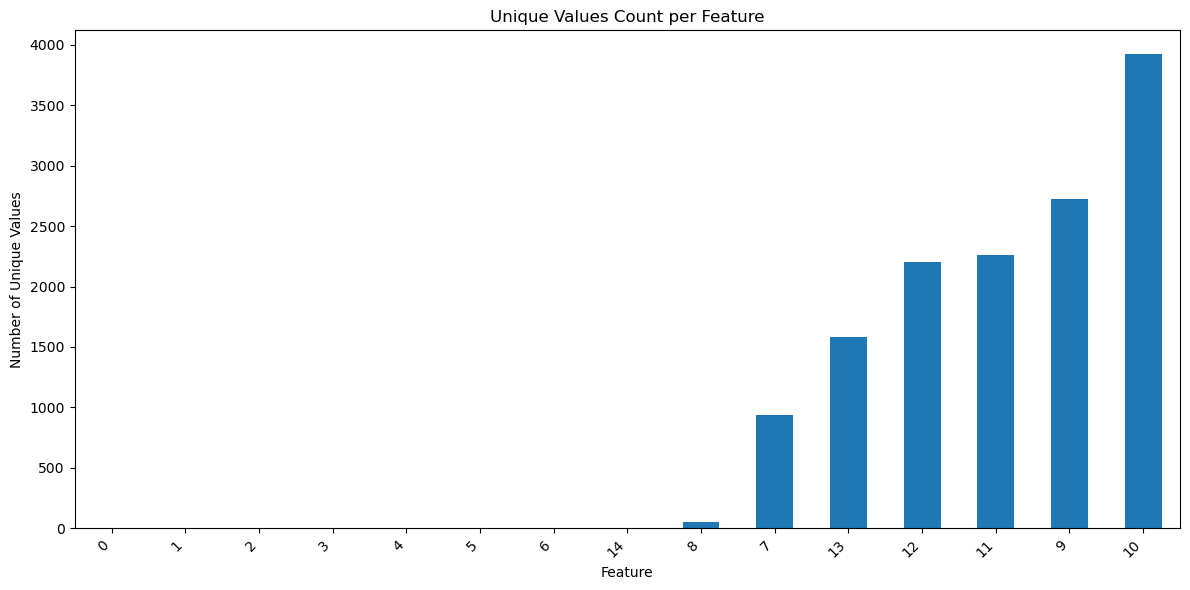

In [149]:
uniques_df = pd.DataFrame(index=df.columns, columns=['count'])
for col in df.columns:
    uniques_df.loc[col, :] = df.loc[:, col].nunique()

uniques_df = uniques_df.sort_values(by='count')

plt.figure(figsize=(12, 6))
uniques_df['count'].plot(kind='bar')
plt.xlabel('Feature')
plt.ylabel('Number of Unique Values')
plt.title('Unique Values Count per Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [151]:
uniques_df

,count
0,2
1,2
2,3
3,3
4,3
5,3
6,3
14,3
8,49
7,934


In [154]:
# df_reset = df.reset_index(drop=True)
categoricals_amount = len(uniques_df[uniques_df['count']<20])
cont_amount = len(uniques_df[uniques_df['count']>=20])

print(f"Amount of categoricals: {categoricals_amount} / {len(df.columns)}")
print(f"Amount of cont features: {cont_amount} / {len(df.columns)}")

Amount of categoricals: 8 / 15
Amount of cont features: 7 / 15


In [158]:
categorical_features = list(uniques_df[uniques_df['count']<20].index)
cont_features = list(uniques_df[uniques_df['count']>=20].index)

### Understand correlation between cont features

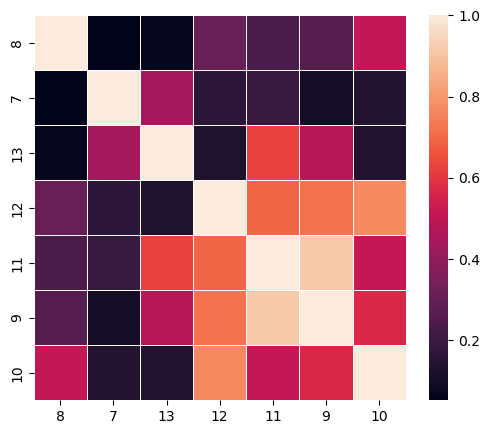

In [160]:
corr = df.loc[:, cont_features].corr(method = 'pearson')
plt.figure(figsize=(6,5))
sns.heatmap(corr,annot=False,fmt=".2f", linewidth=.5)
plt.show()

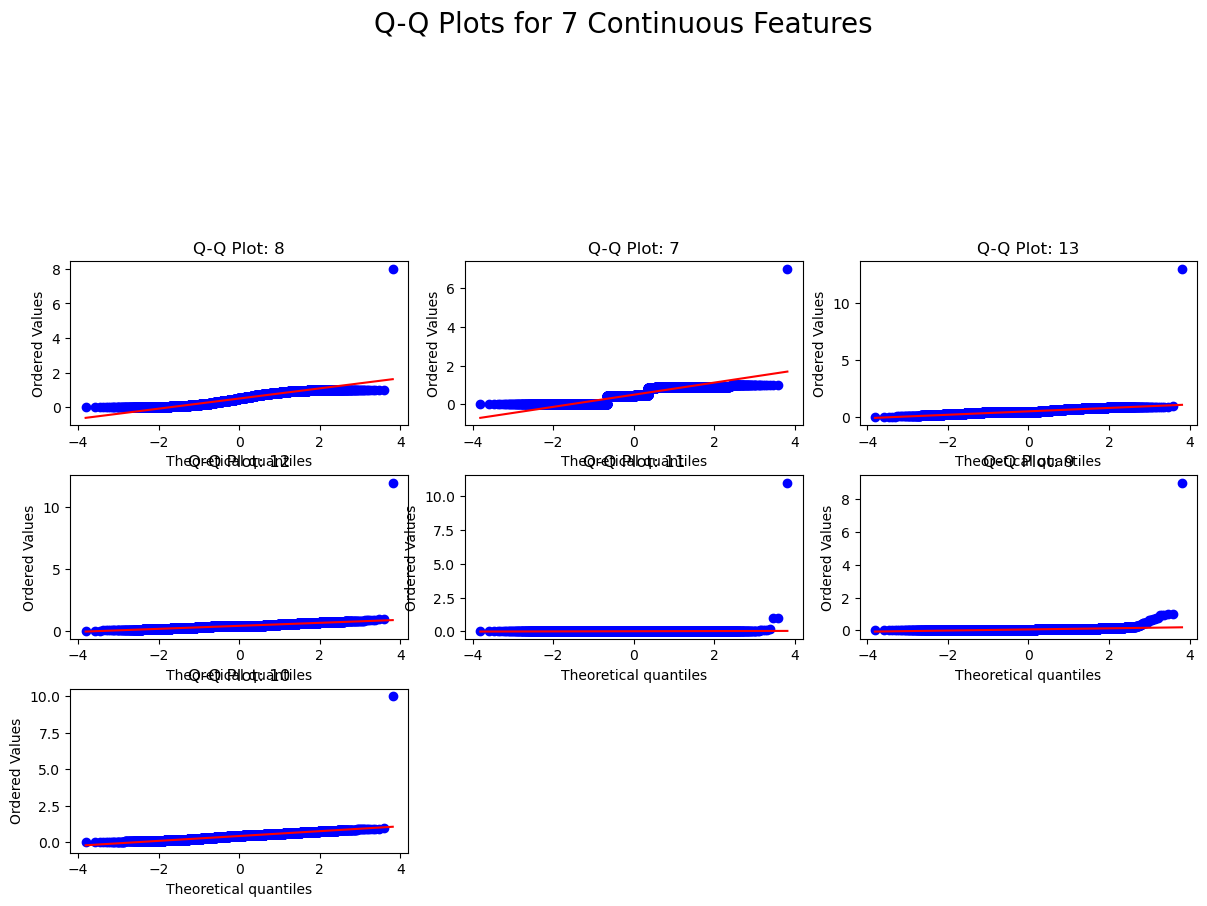

In [162]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# cont_features: list of feature names with >=20 unique values
# Example:
# cont_features = list(uniques_df[uniques_df['count'] >= 20].index)

num_features = len(cont_features)
rows, cols_per_row = 3, 3  # adjust if needed

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 3))
fig.tight_layout(h_pad=3, w_pad=1)
fig.subplots_adjust(top=0.7)

for i, ax in enumerate(axes.flat):
    if i < num_features:
        feature = cont_features[i]
        data = df[feature].dropna()
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f"Q-Q Plot: {feature}", fontsize=12)
    else:
        ax.axis('off')  # Hide unused subplots

fig.suptitle(f"Q-Q Plots for {num_features} Continuous Features", fontsize=20)
plt.show()
